# XGBoost: A Scalable Tree Boosting System
## Replicating Chen & Guestrin (2016) from Scratch

**What is XGBoost?**

XGBoost stands for **eXtreme Gradient Boosting**. It's an optimized gradient boosted decision tree algorithm effective gfor structured/tabular data.

The paper introduced three key innovations:

1. Regularized Objective
- Normal gradient boosting simply minimized prediction error from one inference to another.
    - XGboost adds penalties to the loss function that minimized prediction error
        - Penalizes number of leaves: $\gamma \cdot T$ where $T$ is number of leaves and gamma is a hyperparameter
        - L2 penalty: $\frac{1}{2} \cdot \lambda \cdot |w|^2$ where $w$ is the vector of leaf outputs and $\lambda$ is a hyperparameter

2. Smart split search
- Use quantile sketching to propose better splits of data, don't need to search every split.
    - quantization is confusing, in very simple terms it's dividing all splits in buckets and sampling each bucket
        - XGBoost splits at percentiles (1%, 2%, ...), so ~100 evenly-spaced splits in a given dataset
    - XGBoost weigh the buckets using **hessians** (second derivative of loss wrt prediction)
        - higher hessian samples = sensitive region = do more candidate split points in sensitive region
- Handles missing values automatically (try sending all to left, then try sending all to right and find best gain)

3. System optimizations
- Stores data in sorted columns so split finding can run parallel across different features
- Caches patterns

## Math

### A. Gradient Boosting Idea

We build an ensemble of trees **one at a time**. Each new tree tries to fix the mistakes of all previous trees combined. The prediction after $t$ rounds is:

$$\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)$$

where $f_t$ is the leaf value that sample $x_i$ lands on in new tree we're adding.

### B. XGBoost's Objective Function

$$\mathcal{L} = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)$$

- **First term**: training loss residuals (difference between datapoints and prediction) (e.g., squared error, log loss)
- **Second term**: regularization penalty on tree complexity

As mentioned above, rhe regularization term is composed of:

$$\Omega(f) = \gamma T + \frac{1}{2}\lambda \|w\|^2$$

where $T$ = number of leaves and $w$ = vector of leaf weights. This is what makes XGBoost different from plain gradient boosting, complexity is penalized *within* the objective, not as an afterthought during training.

### C. The Taylor Expansion Trick

Calculating loss at every step $t$ is hard, we can approximate the loss using a 2nd-order Taylor expansion around the current predictions:

$$l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) \approx l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2$$

where:
- $l(y_i, \hat{y}_i^{(t-1)} + f_t(x_i))$ is approximated loss given the current data points $y_i$ and current predictions adjusted by the ouput of the new tree $\hat{y}_i^{(t-1)} + f_t(x_i)$
- $g_i = \frac{\partial l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}}$ is the **gradient** (first derivative of loss w.r.t. prediction)
- $h_i = \frac{\partial^2 l(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2}$ — the **hessian** (second derivative of loss w.r.t. prediction)

By expressing everything in terms of $g$ and $h$, XGBoost works with *any* differentiable loss function. Simply plug in the derivatives.

### D. Optimal Leaf Weight

For a given tree structure, the optimal weight for leaf $j$ is:

$$w_j^* = -\frac{G_j}{H_j + \lambda}$$

- $G_j = \sum_{i \in I_j} g_i$ = sum of all gradients over all samples in leaf $j$.
- $H_j = \sum_{i \in I_j} h_i$ = sum of all hessians over all samples in leaf $j$.

The $\lambda$ term is a regularization hyperparameter, prevents any single leaf from getting an extreme weight.

### E. Split Gain Formula

The gain from splitting a leaf into left and right children:

$$\text{Gain} = \frac{1}{2}\left[\frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda}\right] - \gamma$$

- The first two terms = quality of the two child nodes (left and right)
- The third term = quality of the original unsplit node
- $\gamma$ = minimum gain threshold — acts as built-in pruning
    - this is the same gamma in the objective functions
    - When deriving gain formula, gamma * T penalty means each new split adds one leaf which costs 1 more gamma, hence a split only happens when gain is over gamma.
        - Split must improve predictions by more than gamma to be executed/done, so if gain is lower than gamma, it's not worth the split and we don't split.

## Setup & Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error

np.random.seed(42)

## Load & Explore Data

We use two datasets:
1. **Binary classification**: synthetic data from `make_classification` to test our algorithm
2. **Regression**: California housing (real-world) for final benchmarks

Note: XGBoost doesn't need feature scaling, tree-based methods are invariant to monotonic transformations of features.
- The split isn't affected by scaling, raw values are always going to be split the same way regardless of how they are monotonically (function always increasing or decreasing) scaled

In [2]:
# Dataset 1: Binary classification
X_clf, y_clf = make_classification(n_samples=1000, n_features=10, random_state=42)
X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

# Dataset 2: Regression (California housing)
housing = fetch_california_housing()
X_reg, y_reg = housing.data, housing.target
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Classification data:")
print(f"  Train: {X_clf_train.shape}, Test: {X_clf_test.shape}")
print(f"  Class distribution (train): {np.bincount(y_clf_train)}")

print(f"\nRegression data (California Housing):")
print(f"  Train: {X_reg_train.shape}, Test: {X_reg_test.shape}")
print(f"  Target stats — mean: {y_reg_train.mean():.2f}, std: {y_reg_train.std():.2f}, "
      f"range: [{y_reg_train.min():.2f}, {y_reg_train.max():.2f}]")

Classification data:
  Train: (800, 10), Test: (200, 10)
  Class distribution (train): [412 388]

Regression data (California Housing):
  Train: (16512, 8), Test: (4128, 8)
  Target stats — mean: 2.07, std: 1.16, range: [0.15, 5.00]


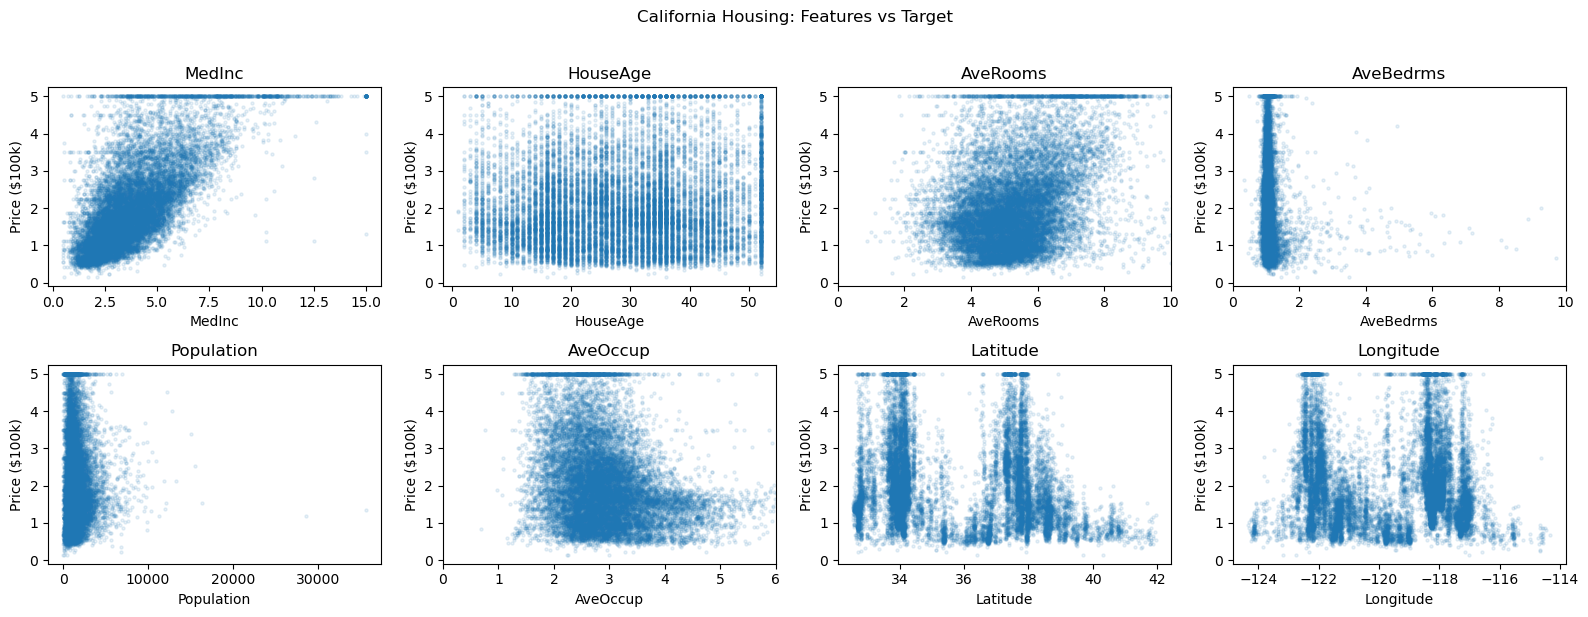

In [10]:
# Visualize a few features vs target feature for the regression dataset
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    ax.scatter(X_reg_train[:, i], y_reg_train, alpha=0.1, s=5)
    ax.set_xlabel(housing.feature_names[i])
    ax.set_ylabel("Price ($100k)")
    ax.set_title(housing.feature_names[i])

    name = housing.feature_names[i]
    if name in ("AveRooms", "AveBedrms"):
        ax.set_xlim(0, 10)
    elif name == "AveOccup":
        ax.set_xlim(0, 6)
plt.suptitle("California Housing: Features vs Target", y=1.02)
plt.tight_layout()
plt.show()

## Decision Stump from Scratch

A decision stump is a tree with depth=1, the simplest building block.
Pick a feature, pick a threshold for the split, group the samples.
- Classification: majority class in group is the class
- Regression: all samples regress to the mean of the group
If we can find the best split for one decision stump we can build XGBoost.

We start with **variance reduction** as the split criterion (for regression). In Phase 2, we'll swap this for the gradient/hessian-based gain formula.
- Split groups are more clustered -> lower variance between group members -> higher variance between members of different groups -> better split

In [20]:
def find_best_split_single_feature(feature_values, targets):
    """Find the best split threshold for a single feature using variance reduction.

    For each unique value, we split into left (<=threshold) and right (>threshold),
    and measure how much the weighted variance decreases.

    Returns: (best_threshold, best_gain) or (None, -inf) if no valid split exists.
    """
    best_gain = -np.inf
    best_threshold = None

    n = len(targets)
    total_var = np.var(targets) * n  # total sum of squared deviations

    sorted_unique = np.unique(feature_values)
    if len(sorted_unique) < 2:
        return None, -np.inf

    for i in range(len(sorted_unique) - 1):
        # sort unique thresholds using midpoints of unique sequential samples
        threshold = (sorted_unique[i] + sorted_unique[i + 1]) / 2.0

        # use masking to sort efficiently
        left_mask = feature_values <= threshold
        right_mask = ~left_mask

        n_left = left_mask.sum()
        n_right = right_mask.sum()
        if n_left == 0 or n_right == 0:
            continue

        # variance reduction = total_var - (left_var + right_var)
        left_var = np.var(targets[left_mask]) * n_left
        right_var = np.var(targets[right_mask]) * n_right
        gain = total_var - (left_var + right_var)

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain

In [21]:
def find_best_split(X, y):
    """Find the best split across all features

    Returns: (best_feature_index, best_threshold, best_gain)
    """
    best_feature = None
    best_threshold = None
    best_gain = -np.inf

    for feat_idx in range(X.shape[1]):
        threshold, gain = find_best_split_single_feature(X[:, feat_idx], y)
        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold
            best_feature = feat_idx

    return best_feature, best_threshold, best_gain

In [22]:
class DecisionStump:
    """A depth-1 decision tree (stump) for regression."""

    def __init__(self):
        self.feature_idx = None
        self.threshold = None
        self.left_value = None
        self.right_value = None

    def fit(self, X, y):
        self.feature_idx, self.threshold, gain = find_best_split(X, y)

        left_mask = X[:, self.feature_idx] <= self.threshold
        self.left_value = y[left_mask].mean()
        self.right_value = y[~left_mask].mean()

        print(f"Best split: feature {self.feature_idx}, threshold {self.threshold:.4f}, gain {gain:.4f}")
        print(f"  Left value: {self.left_value:.4f} ({left_mask.sum()} samples)")
        print(f"  Right value: {self.right_value:.4f} ({(~left_mask).sum()} samples)")

    def predict(self, X):
        left_mask = X[:, self.feature_idx] <= self.threshold
        preds = np.where(left_mask, self.left_value, self.right_value)
        return preds

In [23]:
# Test the stump on regression data
stump = DecisionStump()
stump.fit(X_reg_train, y_reg_train)

# Compare stump MSE vs predicting the mean of the entire dataset (baseline)
stump_preds = stump.predict(X_reg_test)
mean_preds = np.full_like(y_reg_test, y_reg_train.mean())

stump_mse = mean_squared_error(y_reg_test, stump_preds)
baseline_mse = mean_squared_error(y_reg_test, mean_preds)

print(f"\nBaseline MSE (predict mean): {baseline_mse:.4f}")
print(f"Decision Stump MSE:          {stump_mse:.4f}")
print(f"Improvement:                  {(1 - stump_mse / baseline_mse) * 100:.1f}%")

Best split: feature 0, threshold 5.0865, gain 6997.0291
  Left value: 1.7398 (13101 samples)
  Right value: 3.3477 (3411 samples)

Baseline MSE (predict mean): 1.3107
Decision Stump MSE:          0.9441
Improvement:                  28.0%


We can conclude that using a decision stump is better than using the baseline mean to regress, pretty simple and intuitive.

## Implementing XGBoost

Now we want to use the math we learned at the beginning to implement a gradient and hessian based split criterion. This method is better than direct variance reduction because:
- Gradient boosting captures errors of previous trees using gradient and hessian
- Gain formula has regularization to punish magnitude (lambda) and complexity (gamma)
- Gain formula works for any loss function that is differentiable, variance reduction only works for regression.

In [ ]:
class XGBoostTree:
    """A single regularized decision tree for XGBoost.

    This tree is built using gradient and hessian statistics rather than
    raw targets. It uses the XGBoost gain formula for split decisions
    and computes optimal leaf weights analytically.

    Hyperparameters:
        max_depth (int): Maximum depth of the tree
        reg_lambda (float): L2 regularization on leaf weights (lambda)
        gamma (float): Minimum gain required to make a split

    Methods to implement:
        fit(X, gradients, hessians): Build tree using gradient/hessian stats
        predict(X): Return leaf values for each sample
        _find_best_split(X, g, h): Use the gain formula to find optimal splits
        _build_tree(X, g, h, depth): Recursive tree construction with depth limit
    """
    def __init__(self, max_depth, reg_lambda, gamma):
        self.max_depth = max_depth
        self.reg_lambda = reg_lambda
        self.gamma = gamma

        self.tree = None
    
    # Use the features, gradient and hessian computed from all previous trees to find the best split
    def _find_best_split(self, X, g, h):
        best_gain = -np.inf
        best_threshold = None

        sorted_unique = np.unique(X)
        if len(sorted_unique) < 2:
            return None, -np.inf

        for i in range(len(sorted_unique) - 1):
            # sort unique thresholds using midpoints of unique sequential samples
            threshold = (sorted_unique[i] + sorted_unique[i + 1]) / 2.0

            left_mask = X <= threshold
            G_L = g[left_mask].sum()
            H_L = h[left_mask].sum()
            G_R = g[~left_mask].sum()
            H_R = h[~left_mask].sum()

            gain = 0.5 * ((G_L**2 / (H_L + self.reg_lambda)) + (G_R**2 / (H_R + self.reg_lambda)) - ((G_L + G_R)**2 / (H_L + H_R + self.reg_lambda))) - self.gamma

            if gain > best_gain:
                best_gain = gain
                best_threshold = threshold
        return best_threshold, best_gain 

    def _find_best_split_all_features(self, X, g, h):
        best_feature = None
        best_threshold = None
        best_gain = -np.inf

        for i in range(X.shape[1]):
            threshold, gain = self._find_best_split(X[:, i], g, h)
            if gain > best_gain:
                best_feature = i
                best_threshold = threshold
                best_gain = gain
        return best_feature, best_threshold, best_gain
    
    def _build_tree(self, X, g, h):
        pass
            

In [ ]:
class XGBoostModel:
    """Full XGBoost gradient boosting ensemble.

    Builds trees sequentially such that each tree fits the gradient/hessian of the
    loss wrt current predictions. Supports any twice differentiable loss (ex. mse, cross entropy).

    Hyperparameters:
        n_estimators (int): Number of boosting rounds (trees)
        learning_rate (float): Shrinkage factor (eta) applied to each tree
        max_depth (int): Maximum depth per tree
        reg_lambda (float): L2 regularization on leaf weights
        gamma (float): Minimum split gain

    Methods to implement:
        fit(X, y): Additive training — build trees sequentially
        predict(X): Sum base prediction + learning_rate * each tree's prediction
        _compute_gradients(y, y_pred): Compute g_i and h_i for the current loss
    """
    pass